# Raag Recogntion Software


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
import os
from pathlib import Path
import librosa

In [67]:

dir_path = str(Path.cwd())
sound_folder_path =  os.path.join(dir_path, "Data", "Sound")
folder_path_gorakh_kalyan = os.path.join(dir_path, "Data", "Sound", "Gorakh_Kalyan")
folder_path_Jog = os.path.join(dir_path, "Data", "Sound", "Jog")
folder_path_Dharbari = os.path.join(dir_path, "Data", "Sound", "Dharbari")
Sr = 22050  # Common sampling rate for audio processing


In [161]:
list_raags = ['Dharbari','Gorakh_Kalyan','Jog','Kaushi_Kanada','Yaman']
# list_raags = ['Kaushi_Kanada','Yaman']

def get_raag_paths (list_raags, sound_path):
    raag_folders = []
    for raag in list_raags:
        raag_folders.append(os.path.join(sound_path,raag))

    return(raag_folders)

def get_sound_paths(raag_folders):
    sound_paths = {}
    for raag in raag_folders:
        raag = Path(raag)  # ensures Path even if string passed
        sound_paths[raag.name] = []
        for file_path in sorted(raag.glob("*.mp3")):
            sound_paths[raag.name].append(str(file_path))
    return sound_paths

path_folder_list = get_raag_paths(list_raags, sound_folder_path)
print(path_folder_list)
sound_paths = get_sound_paths(path_folder_list)
print(sound_paths)

['c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Dharbari', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Gorakh_Kalyan', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Jog', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Kaushi_Kanada', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Yaman']
{'Dharbari': ['c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Dharbari\\Raag_Dharbari_Sitar.mp3', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\Dharbari\\Raag_Dharbari_Vocal.mp3'], 'Gorakh_Kalyan': ['c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Da

In [3]:
import librosa
import numpy as np


def sliding_spectrograms(audio, sr, window_sec=10, hop_sec=5,
                         n_fft=1024, hop_length=512):
    
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    spectrograms = []

    for start in range(0, len(audio) - window_samples + 1, hop_samples):
        segment = audio[start:start + window_samples]

        # STFT
        S = np.abs(librosa.stft(segment,
                                n_fft=n_fft,
                                hop_length=hop_length))

        # Convert to dB
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        spectrograms.append(S_db)

    return spectrograms

In [4]:

def raag_mel_spectrogram(file_path, start_sec=0, duration=10):
    
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        offset=start_sec,
        duration=duration
    )

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=4096,
        hop_length=512,
        n_mels=128,
        fmin=50,
        fmax=2000
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db, sr


def plot_spectrogram(S_db, sr):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )
    plt.colorbar(label="dB")
    plt.title("Raag Mel Spectrogram")
    plt.tight_layout()
    plt.show()

In [162]:
def generate_raag_dataset(file_path,
                          window_sec=30,
                          hop_sec=15):

    audio, sr = librosa.load(file_path, sr=22050)

    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    dataset = []

    for start in range(0, len(audio) - window_samples + 1, hop_samples):
        segment = audio[start:start + window_samples]

        S = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_fft=4096,
            hop_length=512,
            n_mels=128,
            fmin=50,
            fmax=2000
        )

        dataset.append(librosa.power_to_db(S, ref=np.max))

    return np.array(dataset)

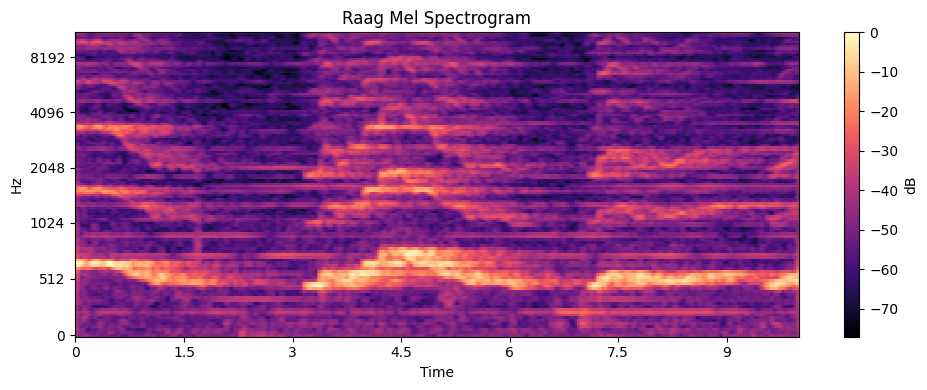

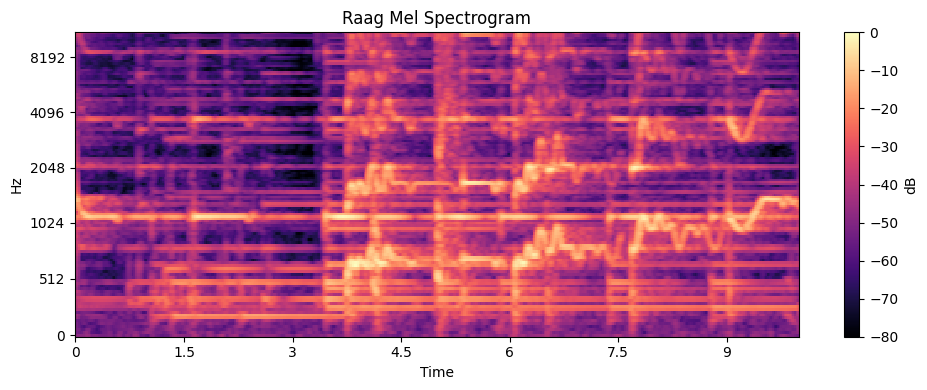

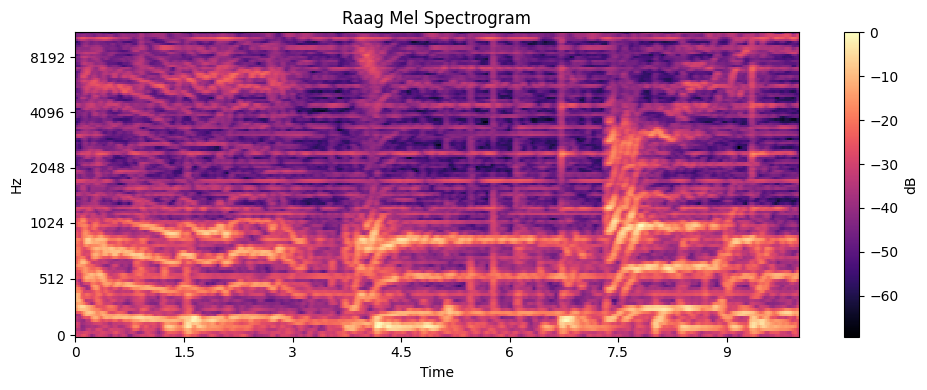

In [ ]:
S_dB_1, Sr = raag_mel_spectrogram(folder_path_gorakh_kalyan, start_sec=500, duration=10)
S_dB_2, Sr = raag_mel_spectrogram(folder_path_Jog, start_sec=800, duration=10)
S_dB_3, Sr = raag_mel_spectrogram(folder_path_Dharbari, start_sec=1000, duration=10)
# data = generate_raag_dataset(file_path, window_sec=10, hop_sec=5)
plot_spectrogram(S_dB_1, Sr)
plot_spectrogram(S_dB_2, Sr)
plot_spectrogram(S_dB_3, Sr)


In [70]:
import matplotlib.pyplot as plt
import os


def save_spectrograms(name,output_dir_GK, data, Sr):
    for i, S_db in enumerate(data):
        plt.figure(figsize=(10, 5))
        librosa.display.specshow(S_db, sr=Sr, x_axis='time', y_axis='hz')
        plt.colorbar()
        plt.title(f"Segment {i}")
        plt.tight_layout()
        plt.savefig(f"{output_dir_GK}/{name}spec_{i:04d}.png")
        plt.close()

In [165]:
for name,sound_path in sound_paths.items():
    for path in sound_path:
        # print(path)
        data = generate_raag_dataset(path, window_sec=30, hop_sec=15)
        print(f"Processing {name} - {path.split('_')[-1]} with {len(data)} segments")
        # data = data[10:]
        output_dir = os.path.join(dir_path, "Data", "Spectrograms", name)
        os.makedirs(output_dir, exist_ok=True)
        save_spectrograms(path.split('_')[-1],output_dir, data, Sr)


Processing Dharbari - Sitar.mp3 with 155 segments
Processing Dharbari - Vocal.mp3 with 229 segments
Processing Gorakh_Kalyan - Bansuri.mp3 with 223 segments
Processing Gorakh_Kalyan - Vocal.mp3 with 116 segments
Processing Jog - Instrumental.mp3 with 73 segments
Processing Jog - Vocal.mp3 with 223 segments
Processing Kaushi_Kanada - Santoor.mp3 with 300 segments
Processing Kaushi_Kanada - Sarod.mp3 with 181 segments
Processing Yaman - Sarangi.mp3 with 252 segments
Processing Yaman - Vocal.mp3 with 211 segments


# CNN

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [166]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATH = os.path.join(dir_path, "Data", "Spectrograms")
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 5

In [167]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [168]:
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size - int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Dharbari', 'Gorakh_Kalyan', 'Jog', 'Kaushi_Kanada', 'Yaman']


In [169]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

model = model.to(device)

In [170]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [171]:
def train_model(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

In [172]:
train_model(model, train_loader, val_loader, EPOCHS)

Epoch 1/5 | Train Acc: 0.347 | Val Acc: 0.575
Epoch 2/5 | Train Acc: 0.578 | Val Acc: 0.753
Epoch 3/5 | Train Acc: 0.707 | Val Acc: 0.819
Epoch 4/5 | Train Acc: 0.756 | Val Acc: 0.840
Epoch 5/5 | Train Acc: 0.814 | Val Acc: 0.847


In [173]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)

train_model(model, train_loader, val_loader, 3)

Epoch 1/3 | Train Acc: 0.883 | Val Acc: 0.941
Epoch 2/3 | Train Acc: 0.960 | Val Acc: 0.967
Epoch 3/3 | Train Acc: 0.984 | Val Acc: 0.990


In [174]:
torch.save({
    "model_state": model.state_dict(),
    "class_names": class_names,
    "image_size": IMG_SIZE
}, "raag_model_full.pth")

In [175]:
checkpoint = torch.load("raag_model_full.pth", map_location=device)

model.load_state_dict(checkpoint["model_state"])
class_names = checkpoint["class_names"]

In [176]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9949


In [89]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues,
                          figsize=(12, 10),
                          fontsize=10):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=fontsize+2)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=60, fontsize=fontsize)
    plt.yticks(tick_marks, classes, fontsize=fontsize)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]:.2f}' if normalize else f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=fontsize)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=fontsize)
    plt.xlabel('Predicted label', fontsize=fontsize)
    plt.show()



In [177]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


Confusion matrix, without normalization
[[39  0  0  0  0]
 [ 0 34  0  0  0]
 [ 0  0 32  0  0]
 [ 0  0  0 47  0]
 [ 1  0  0  0 43]]


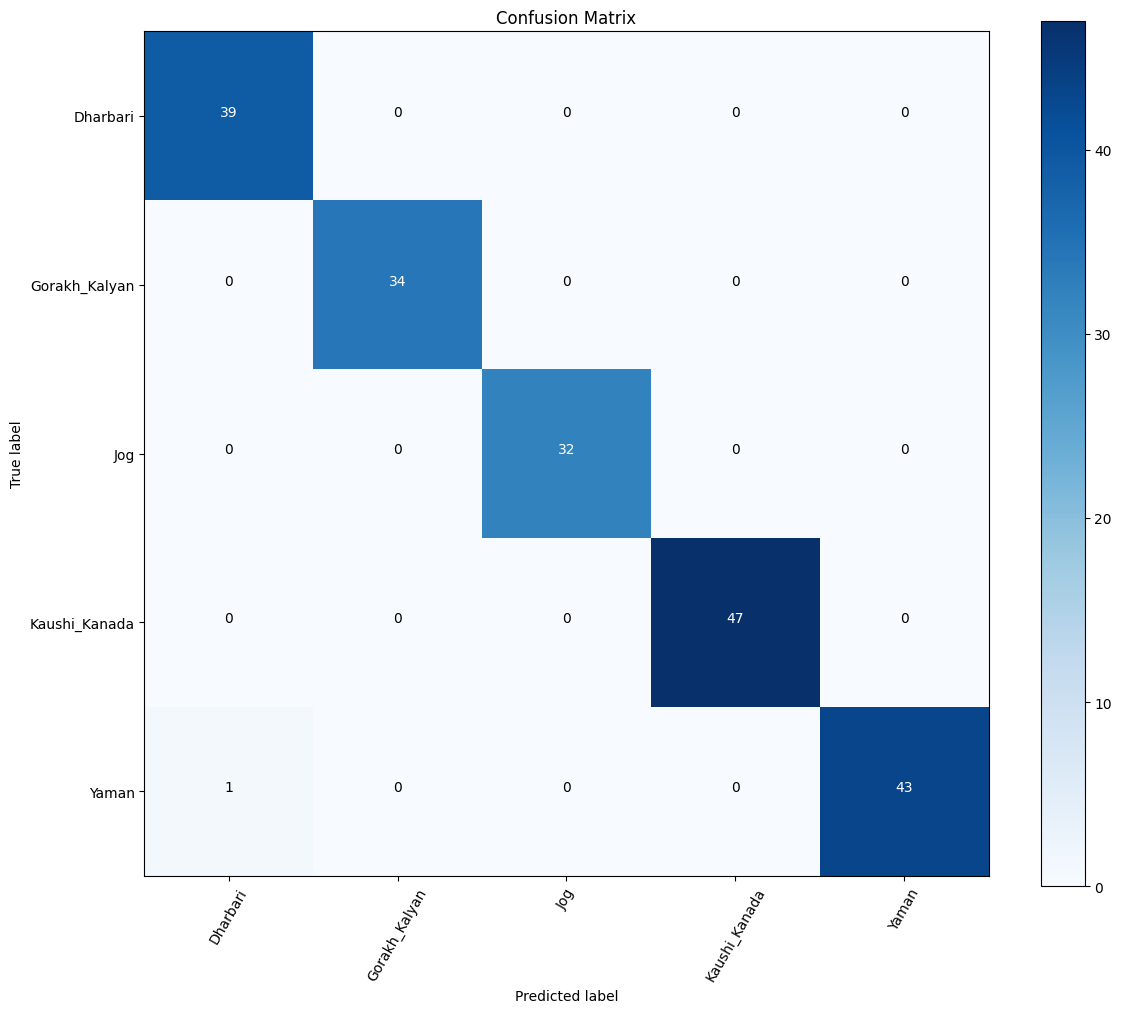

In [178]:
cm = confusion_matrix(all_labels, all_preds)
plot_confusion_matrix(cm,classes = class_names)

# Inference

In [ ]:
import torch
import numpy as np
import librosa

# ---------- YOUR MEL FUNCTION ----------
def raag_mel_spectrogram(file_path, start_sec=0, duration=10):
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        offset=start_sec,
        duration=duration
    )

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=4096,
        hop_length=512,
        n_mels=128,
        fmin=50,
        fmax=2000
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db, sr

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("raag_model_full.pth", map_location=device)

model.load_state_dict(checkpoint["model_state"])
# model.load_state_dict(torch.load("raag_model.pth", map_location=device))
class_names = checkpoint["class_names"]
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [181]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def spectrogram_image(file_path, start_sec=0, duration=30):
    spec, sr = raag_mel_spectrogram(file_path, start_sec, duration)

    fig = plt.figure(figsize=(10, 5))  # ~224×224


    librosa.display.specshow(
        spec,
        sr=sr,
        # cmap="magma",   # must match training
        # fmin=50,
        # fmax=2000
        # x_axis='time',
        # y_axis='Hz'
    )
    # plt.colorbar()

    # plt.tight_layout()

    fig.canvas.draw()

    # ✅ NEW METHOD (matplotlib ≥ 3.8 compatible)
    buf = np.asarray(fig.canvas.buffer_rgba())
    img = Image.fromarray(buf[:, :, :3])  # drop alpha channel

    plt.close(fig)
    plt.show()
    return img

In [182]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [183]:
def preprocess_for_model(file_path, start_sec=0):
    img = spectrogram_image(file_path, start_sec=start_sec)
    tensor = transform(img)
    return tensor.unsqueeze(0).to(device)

In [184]:
LABELS = [
    "Dharbari",
    "Gorakh_Kalyan",
    "Jog",
    "Kaushi_Kanada",
    "Yaman"
    # add your raag names in training order
]

def predict_raag(file_path):
    with torch.no_grad():
        x = preprocess_for_model(file_path)
        output = model(x)

        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    return LABELS[pred_idx], confidence

In [ ]:
file_path = os.path.join(dir_path,"Data", "Inference", "test_sarangi_yaman.mp3")
x = preprocess_for_model(file_path)
# print(x.shape)
# print(x.min().item(), x.max().item(), x.mean().item())

label, conf = predict_raag(file_path)
print(f"Predicted: {label} | Confidence: {conf:.3f}")

torch.Size([1, 3, 224, 224])
-2.015155553817749 2.640000104904175 0.7106719613075256
Predicted: Yaman | Confidence: 0.337
